In [18]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

PRE-PROCESSING

import os
from PIL import Image

ip_folders = ['Bar Chart', 'Class Diagram',  'Flow Chart', 'Line Chart', 'Pie Chart', 'Usecase Diagram']
op_folders = ['Bar Chart', 'Class Diagram', 'Flow Chart', 'Line Chart', 'Pie Chart', 'Usecase Diagram']

for i in range(len(ip_folders)):
    ip = ip_folders[i]
    op = op_folders[i]
    # Folder containing the palette images
    input_folder = 'FinalDataSet/Test/' + ip
    output_folder = 'DataSet/Test/' + op
    
    # Create the output folder if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Loop through all files in the folder
    for filename in os.listdir(input_folder):
        try:
            if filename.endswith('.png') or filename.endswith('.jpg'):  # Check if it's an image file
                # Full path to the image
                input_image_path = os.path.join(input_folder, filename)
                
                # Open the palette image
                palette_image = Image.open(input_image_path)
        
                # Convert to RGBA format
                rgba_image = palette_image.convert("RGB")
        
                # Save the converted image to the output folder
                output_image_path = os.path.join(output_folder, filename)
                rgba_image.save(output_image_path, 'JPEG')
        
                print(f"Converted {filename} to RGBA and saved to {output_folder}")
        except Exception as e:
            print(e)
            continue
    
    print("Conversion completed for all images in the folder.")


In [19]:
train_dir = 'DataSet/Train/'
test_dir = 'DataSet/Test/'

train_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input, validation_split=0.2)
test_datagen = ImageDataGenerator(preprocessing_function=tf.keras.applications.resnet50.preprocess_input)

train_generator = train_datagen.flow_from_directory(train_dir, batch_size=32, target_size=(224, 224), class_mode='categorical', color_mode='rgb', shuffle=True, seed=42, subset='training')
valid_generator = train_datagen.flow_from_directory(train_dir, batch_size=32, target_size=(224, 224), class_mode='categorical', color_mode='rgb', shuffle=False, subset='validation')
test_generator = test_datagen.flow_from_directory(test_dir, batch_size=32, target_size=(224, 224), class_mode='categorical', color_mode='rgb', shuffle=False)

Found 1304 images belonging to 6 classes.
Found 324 images belonging to 6 classes.
Found 468 images belonging to 6 classes.


TRAINING

In [20]:
preTrained_model = ResNet50(include_top=False, input_shape=(224, 224, 3), pooling='avg', weights='imagenet')
preTrained_model.trainable = False

In [21]:
inputs = preTrained_model.input
x = Dense(128, activation='relu')(preTrained_model.output)
x = Dense(50, activation='relu')(x)
outputs = Dense(6, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

In [22]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_pad (ZeroPadding2D)     │ (None, 230, 230, 3)       │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_conv (Conv2D)           │ (None, 112, 112, 64)      │           9,472 │ conv1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_bn (BatchNormalization) │ (None, 112, 112, 64)      │             256 │ conv1_conv[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1_relu (Activation)       │ (None, 112, 112, 64)      │               0 │ conv1_bn[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pad (ZeroPadding2D)     │ (None, 114, 114, 64)      │               0 │ conv1_relu[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ pool1_pool (MaxPooling2D)     │ (None, 56, 56, 64)        │               0 │ pool1_pad[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_conv (Conv2D)  │ (None, 56, 56, 64)        │           4,160 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_1_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_1_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_1_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_conv (Conv2D)  │ (None, 56, 56, 64)        │          36,928 │ conv2_block1_1_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_bn             │ (None, 56, 56, 64)        │             256 │ conv2_block1_2_conv[0][0]  │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_2_relu           │ (None, 56, 56, 64)        │               0 │ conv2_block1_2_bn[0][0]    │
│ (Activation)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_0_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ pool1_pool[0][0]           │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2_block1_3_conv (Conv2D)  │ (None, 56, 56, 256)       │          16,640 │ conv2_block1_2_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 23,856,740 (91.01 MB)

 Trainable params: 269,028 (1.03 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [23]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [24]:
callbacks = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)
history = model.fit(train_generator, epochs=25, validation_data=valid_generator, callbacks=[callbacks])

Epoch 1/25


C:\Users\pc\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


41/41 ━━━━━━━━━━━━━━━━━━━━ 122s 3s/step - accuracy: 0.6111 - loss: 1.0982 - val_accuracy: 0.9414 - val_loss: 0.1690
Epoch 2/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 108s 3s/step - accuracy: 0.9518 - loss: 0.1544 - val_accuracy: 0.9599 - val_loss: 0.1072
Epoch 3/25
41/41 ━━━━━━━━━━━━━━━━━━━━ 107s 3s/step - accuracy: 0.9796 - loss: 0.0774 - val_accuracy: 0.9568 - val_loss: 0.1258


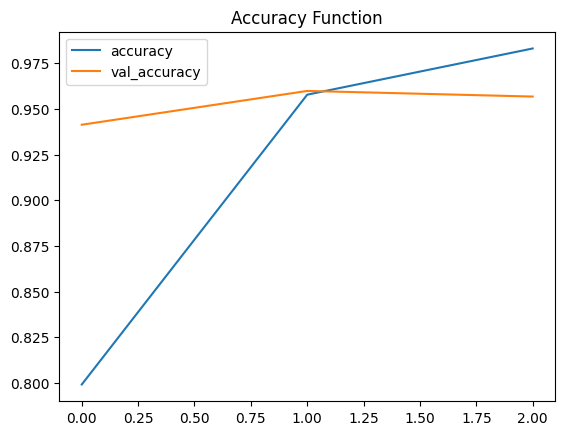

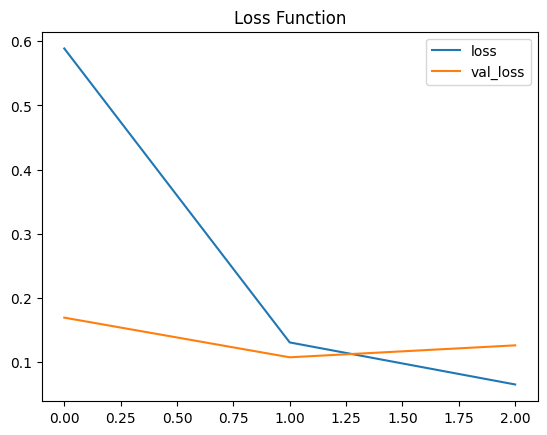

In [25]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Accuracy Function')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Function')
plt.legend()
plt.show()

In [26]:
model.evaluate(valid_generator)

11/11 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9486 - loss: 0.1322


[0.10717466473579407, 0.959876537322998]

In [27]:
y_pred = np.argmax(model.predict(valid_generator), axis=1)
y_true = valid_generator.classes
target_names = valid_generator.class_indices.keys()
report = classification_report(y_pred, y_true, target_names=target_names, zero_division=0)

11/11 ━━━━━━━━━━━━━━━━━━━━ 27s 2s/step


In [28]:
print(report)

                 precision    recall  f1-score   support

      Bar Chart       0.94      1.00      0.97        51
  Class Diagram       0.90      0.96      0.93        46
     Flow Chart       0.97      0.90      0.93        62
     Line Chart       1.00      0.92      0.96        59
      Pie Chart       1.00      1.00      1.00        57
Usecase Diagram       0.94      1.00      0.97        49

       accuracy                           0.96       324
      macro avg       0.96      0.96      0.96       324
   weighted avg       0.96      0.96      0.96       324



In [29]:
from sklearn.metrics import confusion_matrix

In [30]:
cm = confusion_matrix(y_true, y_pred)

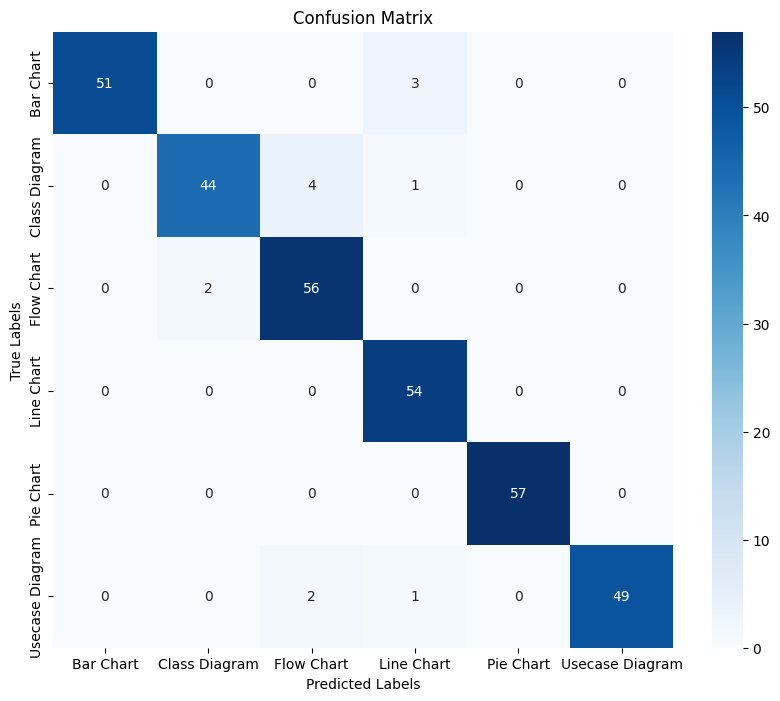

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=valid_generator.class_indices.keys(), yticklabels=valid_generator.class_indices.keys())
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

In [32]:
model.save('myModel.keras')
model.save_weights('myModel.weights.h5')